# Neural Network Theory Questions

Question 1: What is Deep Learning? Briefly describe how it evolved and how it differs from traditional machine learning.

  - Answer:
Deep Learning is a subset of machine learning that uses multi-layer neural networks to learn patterns from data. It evolved with the availability of large datasets and high computational power like GPUs. Unlike traditional ML, it automatically extracts features instead of manual feature engineering. It performs well in complex tasks like image and speech recognition.

Question 2: Explain the basic architecture and functioning of a Perceptron. What are its limitations?

  - Answer:
A Perceptron is a single-layer neural network that computes a weighted sum of inputs and applies an activation function. It is mainly used for binary classification tasks. Its main limitation is that it can only solve linearly separable problems. It cannot handle complex patterns like XOR due to the absence of hidden layers.

Question 3: Describe the purpose of activation function in neural networks. Compare Sigmoid, ReLU, and Tanh functions.

  - Answer:
Activation functions introduce non-linearity, allowing neural networks to learn complex patterns. Sigmoid outputs values between 0 and 1 but suffers from vanishing gradients. ReLU outputs max(0, x) and is efficient but may cause dead neurons. Tanh outputs between -1 and 1 and performs better than sigmoid but still faces vanishing gradient issues.

Question 4: What is the difference between Loss function and Cost function in neural networks? Provide examples.

  - Answer:
A Loss function measures the error for a single training example, while a Cost function is the average of losses over the entire dataset. Loss helps in individual prediction evaluation, whereas cost measures overall model performance. Examples include Mean Squared Error and Binary Crossentropy. Cost is used during optimization.

Question 5: What is the role of optimizers in neural networks? Compare Gradient Descent, Adam, and RMSprop.

  - Answer:
Optimizers update model weights to minimize the loss function. Gradient Descent is simple but slow and may get stuck in local minima. Adam combines momentum and adaptive learning rates, making it fast and efficient. RMSprop adapts learning rates based on recent gradients and works well for dynamic data.

Question 10: Fraud Detection Workflow

Answer:
  - A multilayer neural network can be used to capture complex patterns in transaction data. ReLU can be used in hidden layers and Sigmoid in the output layer with Binary Crossentropy loss. Handle class imbalance using class weights or resampling techniques like SMOTE. Use Adam optimizer and prevent overfitting with dropout, early stopping, and regularization.

# Neural Network Practical Questions

In [1]:
# Question 6: Write a Python program to implement a single-layer perceptron from scratch using NumPy to solve the logical AND gate.

import numpy as np

X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([0, 0, 0, 1])

weights = np.zeros(2)
bias = 0
lr = 0.1

def step(x):
    return 1 if x >= 0 else 0

for epoch in range(10):
    for i in range(len(X)):
        output = np.dot(X[i], weights) + bias
        pred = step(output)
        error = y[i] - pred
        weights += lr * error * X[i]
        bias += lr * error

for x in X:
    print(x, "->", step(np.dot(x, weights) + bias))

[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1


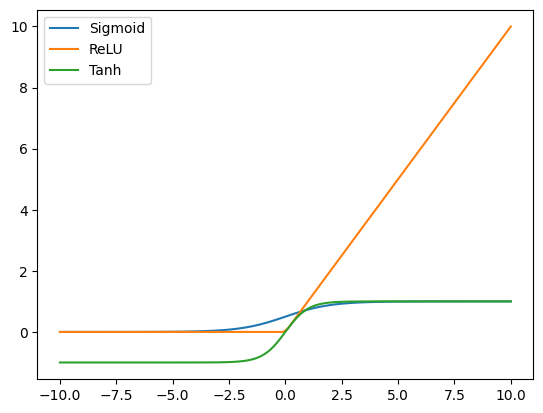

In [2]:
# Question 7: Implement and visualize Sigmoid, ReLU, and Tanh activation functions using Matplotlib.

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)

sigmoid = 1 / (1 + np.exp(-x))
relu = np.maximum(0, x)
tanh = np.tanh(x)

plt.plot(x, sigmoid, label="Sigmoid")
plt.plot(x, relu, label="ReLU")
plt.plot(x, tanh, label="Tanh")

plt.legend()
plt.show()

In [3]:
# Question 8: Use Keras to build and train a simple multilayer neural network on the MNIST digits dataset. Print the training accuracy.

import tensorflow as tf
from tensorflow import keras

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=5)

loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9252 - loss: 0.2614
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9675 - loss: 0.1123
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9763 - loss: 0.0772
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9815 - loss: 0.0579
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9864 - loss: 0.0446
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9763 - loss: 0.0755
Accuracy: 0.9763000011444092


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8249 - loss: 0.4976 - val_accuracy: 0.8504 - val_loss: 0.4200
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8651 - loss: 0.3748 - val_accuracy: 0.8467 - val_loss: 0.4403
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8766 - loss: 0.3373 - val_accuracy: 0.8756 - val_loss: 0.3542
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8858 - loss: 0.3127 - val_accuracy: 0.8716 - val_loss: 0.3532
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8912 - loss: 0.2956 - val_accuracy: 0.8739 - val_loss: 0.3496


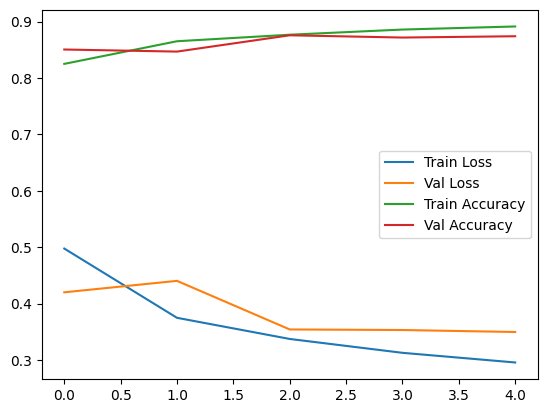

In [4]:
# Question 9: Visualize the loss and accuracy curves for a neural network model trained on the Fashion MNIST dataset. Interpret the training behavior.

import matplotlib.pyplot as plt
from tensorflow import keras

(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')

plt.legend()
plt.show()